# Assignment 1

Deadline: 19.03.2025, 12:00 CET

<Add your name, student-id and emal address>

In [33]:
# Import standard libraries
import os
import sys
import timeit # To compute runtimes
from typing import Optional

# Import third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import local modules
project_root = os.path.dirname(os.path.dirname(os.getcwd()))   # Change this path if needed
src_path = os.path.join(project_root, 'qpmwp-course//src')
sys.path.append(project_root)
sys.path.append(src_path)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization import Optimization, Objective
from optimization.optimization_data import OptimizationData
from optimization.quadratic_program import QuadraticProgram, USABLE_SOLVERS

## 1. Solver horse race

### 1.a)
(3 points)

Generate a Multivariate-Normal random dataset of dimension TxN, T=1000, N=100, and compute a vector of expected returns, q, and a covariance matrix, P, using classes ExpectedReturn and Covariance respectively.

In [51]:

# Set the dimensions
T = 1000  # Number of time periods
N = 100   # Number of assets

# Generate a random mean vector and covariance matrix for the multivariate normal distribution
mean = np.zeros(N)
random_matrix = np.random.rand(N,T)
cov = np.cov(random_matrix)

# Generate the Multivariate-Normal random dataset
data = data = np.random.multivariate_normal(mean, cov, size = T)

# Convert the dataset to a DataFrame for easier manipulation
df = pd.DataFrame(data, columns=[f'Asset_{i+1}' for i in range(N)])

# Compute the vector of expected returns (mean returns) from df
q = ExpectedReturn().estimate(df, inplace=False)

# Compute the covariance matrix from df
P = Covariance().estimate(df, inplace=False)

# Display the results
print("Vector of expected returns (q):")
print(q)

print("\nCovariance matrix (P):")
print(P)

Vector of expected returns (q):
Asset_1     -0.052437
Asset_2     -0.048075
Asset_3     -0.058545
Asset_4     -0.056125
Asset_5     -0.060997
               ...   
Asset_96    -0.049461
Asset_97    -0.045806
Asset_98    -0.041664
Asset_99    -0.053928
Asset_100   -0.043398
Length: 100, dtype: float64

Covariance matrix (P):
            Asset_1   Asset_2   Asset_3   Asset_4   Asset_5   Asset_6  \
Asset_1    0.085874  0.002344  0.004636  0.004520  0.003776 -0.003280   
Asset_2    0.002344  0.073863  0.006063  0.003657 -0.004724  0.001616   
Asset_3    0.004636  0.006063  0.086423 -0.002715  0.000706 -0.001859   
Asset_4    0.004520  0.003657 -0.002715  0.087638 -0.007355  0.000774   
Asset_5    0.003776 -0.004724  0.000706 -0.007355  0.077321  0.001346   
...             ...       ...       ...       ...       ...       ...   
Asset_96   0.002726 -0.007518 -0.002377 -0.003414 -0.002139  0.002160   
Asset_97  -0.000781 -0.006856  0.001250 -0.001749 -0.002475  0.002865   
Asset_98   0.0019

/home/patsias/.local/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


### 1.b)
(3 points)

Instantiate a constraints object by injecting column names of the data created in 1.a) as ids and add:
- a budget constaint (i.e., asset weights have to sum to one)
- lower bounds of 0.0 for all assets
- upper bounds of 0.2 for all assets
- group contraints such that the sum of the weights of the first 30 assets is <= 0.3, the sum of assets 31 to 60 is <= 0.4 and the sum of assets 61 to 100 is <= 0.5

In [ ]:
# Instantiate the Constraints class
constraints = Constraints(ids = df.columns.tolist())
# Add budget constraint
constraints.add_budget()
# Add box constraints (i.e., lower and upper bounds)
constraints.add_box(lower = 0.0,upper = 0.2)
# Add linear constraints
group_constraints = [
    (list(df.columns[:30]), 0.3),   
    (list(df.columns[30:60]), 0.4), 
    (list(df.columns[60:]), 0.5)    
]

# Add each group constraint properly
for group, max_weight in group_constraints:
    # print(group)
    constraint_vector = pd.Series(0, index=df.columns)  
    constraint_vector[group] = 1  
    print(constraint_vector)
    constraints.add_linear(G=None, g_values=constraint_vector, sense='<=', rhs=max_weight)

Asset_1      1
Asset_2      1
Asset_3      1
Asset_4      1
Asset_5      1
            ..
Asset_96     0
Asset_97     0
Asset_98     0
Asset_99     0
Asset_100    0
Length: 100, dtype: int64
Asset_1      0
Asset_2      0
Asset_3      0
Asset_4      0
Asset_5      0
            ..
Asset_96     0
Asset_97     0
Asset_98     0
Asset_99     0
Asset_100    0
Length: 100, dtype: int64
Asset_1      0
Asset_2      0
Asset_3      0
Asset_4      0
Asset_5      0
            ..
Asset_96     1
Asset_97     1
Asset_98     1
Asset_99     1
Asset_100    1
Length: 100, dtype: int64


### 1.c) 
(4 points)

Solve a Mean-Variance optimization problem (using coefficients P and q in the objective function) which satisfies the above defined constraints.
Repeat the task for all open-source solvers in qpsolvers and compare the results in terms of:

- runtime
- accuracy: value of the primal problem.
- reliability: are all constarints fulfilled? Extract primal resisduals, dual residuals and duality gap.

Generate a DataFrame with the solvers as column names and the following row index: 'solution_found': bool, 'objective': float, 'primal_residual': float, 'dual_residual': float, 'duality_gap': float, 'runtime': float.

Put NA's for solvers that failed for some reason (e.g., unable to install the package or solvers throws an error during execution). 




In [36]:
import time
# Extract the constraints in the format required by the solver
GhAb = constraints.to_GhAb()
G,h = GhAb["G"], GhAb["h"]
A,b = GhAb["A"], GhAb["b"]
# Loop over solvers, instantiate the quadratic program, solve it and store the results
results = {}
risk_aversion = 1
for solver in USABLE_SOLVERS:
    try:
        qp = QuadraticProgram(
            P = P.to_numpy() * risk_aversion,
            q = q.to_numpy() * -1,
            G = GhAb['G'],
            h = GhAb['h'],
            A = GhAb['A'],
            b = GhAb['b'],
            lb = constraints.box['lower'].to_numpy(),
            ub = constraints.box['upper'].to_numpy(),
            solver = solver,
            sparse = True
        )
        start_time = time.time()
        qp.solve()
        end_time = time.time()
        runtime = end_time - start_time  # in seconds
        sol = qp.results['solution']
        results[solver] = {
            "solution_found": sol.found ,
            "objective": qp.objective_value() ,
            "primal_residual": sol.primal_residual() ,
            "dual_residual": sol.dual_residual() ,
            "duality_gap": sol.duality_gap()[0] ,
            "runtime": runtime
        }
    except Exception as e:
        print(f"Solver {solver} failed: {str(e)}")
        results[solver] = {
            "solution_found": False,
            "objective": None,
            "primal_residual": None,
            "dual_residual": None,
            "duality_gap": None,
            "runtime": None
        }
    df_results = pd.DataFrame(results)
    

Print and visualize the results

In [37]:
df_results

,highs,cvxopt,qpalm,osqp,daqp,quadprog
solution_found,True,True,True,True,True,True
objective,0.036175,0.036175,0.036172,0.036174,0.036175,0.036175
primal_residual,0.0,0.0,0.000018,0.000005,0.0,0.0
dual_residual,0.0,0.0,0.0,0.000002,0.0,0.0
duality_gap,0.0,0.0,0.000003,0.0,0.0,0.0
runtime,0.03708,0.057667,0.021794,0.00788,0.004195,0.006296


{'highs': {'solution_found': True, 'objective': 0.03617454499043873, 'primal_residual': np.float64(1.1102230246251565e-16), 'dual_residual': np.float64(1.9999999996411777e-08), 'duality_gap': np.float64(8.644673983593254e-09), 'runtime': 0.03708004951477051}, 'cvxopt': {'solution_found': True, 'objective': 0.03617455095829934, 'primal_residual': np.float64(2.220446049250313e-16), 'dual_residual': np.float64(9.506284648352903e-16), 'duality_gap': np.float64(6.3026950110236894e-09), 'runtime': 0.05766701698303223}, 'qpalm': {'solution_found': True, 'objective': 0.0361716797594627, 'primal_residual': np.float64(1.7837016624546224e-05), 'dual_residual': np.float64(4.78510703283419e-10), 'duality_gap': np.float64(2.8637925448334885e-06), 'runtime': 0.021793842315673828}, 'osqp': {'solution_found': True, 'objective': 0.03617443256497284, 'primal_residual': np.float64(4.734945814710567e-06), 'dual_residual': np.float64(1.6362051745918982e-06), 'duality_gap': np.float64(3.3480631939691234e-07)

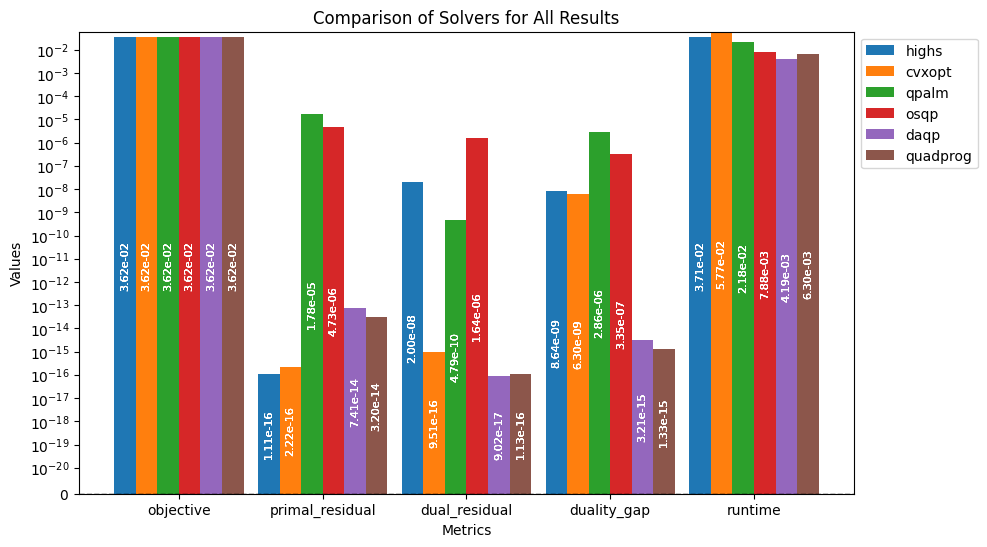

In [38]:
print(results)

numeric_results = df_results.drop("solution_found")

solvers = numeric_results.columns.values
metrics = numeric_results.index.values

x = np.arange(len(metrics))
width = 0.15

fig, ax = plt.subplots(figsize=(10, 6))

for i, solver in enumerate(solvers):
    bars = ax.bar(x + i * width, numeric_results[solver].values, width, label=solver)
    for bar in bars:
        ax.bar_label(bars, fmt="%.2e", rotation=90, fontsize=8, label_type="center", color="white")

ax.set_xlabel("Metrics")
ax.set_ylabel("Values")
ax.set_title("Comparison of Solvers for All Results")
ax.set_xticks(x + (len(solvers) - 1)/2 * width)
ax.set_xticklabels(metrics)
ax.set_yscale("symlog", linthresh=1e-20)
ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))

## 2. Analytical Solution to Minimum-Variance Problem

(5 points)

- Create a `MinVariance` class that follows the structure of the `MeanVariance` class.
- Implement the `solve` method in `MinVariance` such that if `solver_name = 'analytical'`, the analytical solution is computed and stored within the object (if such a solution exists). If not, call the `solve` method from the parent class.
- Create a `Constraints` object by injecting the same ids as in part 1.b) and add a budget constraint.
- Instantiate a `MinVariance` object by setting `solver_name = 'analytical'` and passing instances of `Constraints` and `Covariance` as arguments.
- Create an `OptimizationData` object that contains an element `return_series`, which consists of the synthetic data generated in part 1.a).
- Solve the optimization problem using the created `MinVariance` object and compare the results to those obtained in part 1.c).


In [40]:
# Define class MinVariance
class MinVariance(Optimization):

    def __init__(self,
                 constraints: Constraints,
                 covariance: Optional[Covariance] = None,
                 **kwargs):
        super().__init__(
            constraints=constraints,
            **kwargs
        )
        self.covariance = Covariance() if covariance is None else covariance

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        
        self.objective = Objective(
            P=covmat * 2,  # Quadratic term (multiplied by 2 for solver consistency)
            q=np.zeros(len(covmat))  # No linear term (we only minimize risk)
        )

    def solve(self) -> None:
        if self.params.get('solver_name') == 'analytical':
            var = self.objective.coefficients["P"]/2
            var_T = np.linalg.inv(var)
            A = np.array(self.constraints.budget['Amat'], dtype='d').reshape(1, -1)
            b = np.array([[self.constraints.budget['rhs']]], dtype='d')
            x = var_T @ A.T @ np.linalg.inv(A @ var_T @ A.T) @ b

            self.results.update( {self.constraints.ids[i] : x[i][0] for i in range(len(self.constraints.ids))})


            return None
        else:
            return super().solve()


# Create a constraints object with just a budget constraint
constraints = Constraints(ids = df.columns.tolist())
constraints.add_budget()

# Instantiate the MinVariance class
min_var = MinVariance(constraints,covariance = Covariance())

# Prepare the optimization data and prepare the optimization problem
opt_data = OptimizationData(return_series=df)
min_var.set_objective(optimization_data=opt_data)

# Solve the optimization problem and print the weights
min_var.solve()
print(min_var.results)

{'Asset_1': np.float64(0.009113492033412518), 'Asset_2': np.float64(0.016553458593975084), 'Asset_3': np.float64(0.012394522689373957), 'Asset_4': np.float64(0.0060292436914251525), 'Asset_5': np.float64(0.017304249007452366), 'Asset_6': np.float64(0.0078045261508760825), 'Asset_7': np.float64(0.009903076209484891), 'Asset_8': np.float64(0.011680032338801095), 'Asset_9': np.float64(0.007829263970399397), 'Asset_10': np.float64(0.0076346750422899064), 'Asset_11': np.float64(0.013369625735952382), 'Asset_12': np.float64(0.01277849434254989), 'Asset_13': np.float64(0.007914451422608432), 'Asset_14': np.float64(0.006295221779230843), 'Asset_15': np.float64(0.004059399554367683), 'Asset_16': np.float64(-0.0009288109457670159), 'Asset_17': np.float64(0.015286573344293859), 'Asset_18': np.float64(0.015187057862681526), 'Asset_19': np.float64(0.008875550238676689), 'Asset_20': np.float64(0.007688969739142588), 'Asset_21': np.float64(0.017209865481047547), 'Asset_22': np.float64(0.0069435149406